#Bibliotecas:

In [32]:
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

#Escolha do local do Grafo

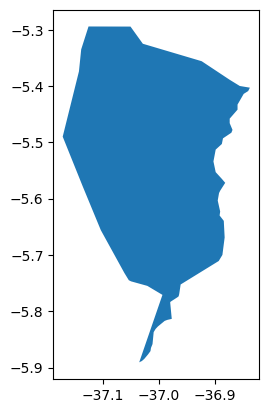

In [33]:
place = "Assu, Brazil"

edge = ox.geocode_to_gdf(place)

edge.plot()
plt.savefig("images/municipio_borda.svg", dpi=300, bbox_inches='tight')

Arestas em G_undirected: 4319


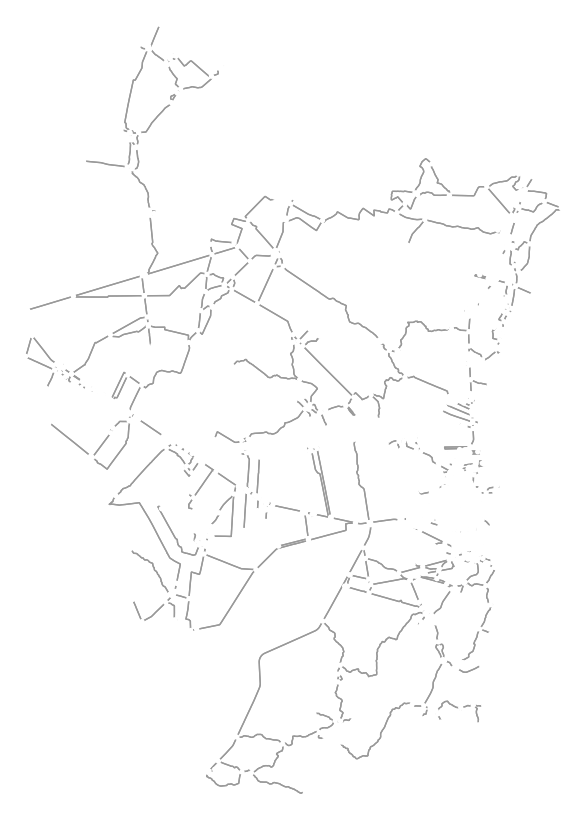

In [34]:
G = ox.graph_from_place(place, network_type="drive")

fig, ax = ox.plot_graph(G, show=False, save=True, filepath="images/grafo.svg", dpi=300)

G_undirected = ox.convert.to_undirected(G)

print(f"Arestas em G_undirected: {G_undirected.number_of_edges()}")

#Análise Estrutural e Hubs

In [35]:
degree = dict(G_undirected.degree())

degree_centrality = nx.degree_centrality(G_undirected)

closeness_centrality = nx.closeness_centrality(G_undirected)

betweenness_centrality = nx.betweenness_centrality(G_undirected, normalized=True)

G_simples = nx.Graph(G_undirected)
eigenvector_centrality = nx.eigenvector_centrality(G_simples, max_iter=1000)

df_metricas = pd.DataFrame({
    'Degree': degree,
    'Degree_Centrality': degree_centrality,
    'Closeness': closeness_centrality,
    'Betweenness': betweenness_centrality,
    'Eigenvector': eigenvector_centrality
})

df_metricas.sort_values(by='Betweenness', ascending=False).head(5)

,Degree,Degree_Centrality,Closeness,Betweenness,Eigenvector
6258979020,3,0.001017,0.028252,0.250245,4.606332e-09
2085821372,3,0.001017,0.028822,0.249809,3.320318e-08
7050682147,3,0.001017,0.028533,0.249790,1.215790e-08
7053390191,3,0.001017,0.030714,0.249683,2.136319e-06
6258979017,3,0.001017,0.027977,0.243845,1.739196e-09


In [36]:
def obter_ruas_do_no_melhorado(node_id, grafo):
    ruas = set() 
    
    for u, v, data in grafo.edges(node_id, data=True):
        nome = data.get('name')
        ref = data.get('ref')        
        tipo = data.get('highway')   
        
        identificador = None

        if nome:
            identificador = nome if isinstance(nome, str) else nome[0]
        elif ref:
            identificador = f"Rodovia {ref if isinstance(ref, str) else ref[0]}"
        elif tipo:
            tipo_str = tipo if isinstance(tipo, str) else tipo[0]
            identificador = f"Via tipo '{tipo_str}'"
        if identificador:
            ruas.add(identificador)
            
    if ruas:
        return " Cruzamento: " + " / ".join(ruas)
    else:
        return "Via não classificada no OSM"

df_metricas['Cruzamento'] = [obter_ruas_do_no_melhorado(n, G_undirected) for n in df_metricas.index]

pd.set_option('display.max_colwidth', None)

cols = ['Cruzamento', 'Betweenness', 'Degree'] 
df_metricas.sort_values(by='Betweenness', ascending=False)[cols].head(5)

,Cruzamento,Betweenness,Degree
6258979020,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,0.250245,3
2085821372,Cruzamento: Via tipo 'trunk_link' / Rodovia BR-304,0.249809,3
7050682147,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,0.249790,3
7053390191,Cruzamento: Via tipo 'residential' / Rodovia BR-304,0.249683,3
6258979017,Cruzamento: Via tipo 'unclassified',0.243845,3


In [37]:
G_simples.remove_edges_from(nx.selfloop_edges(G_simples))

core_numbers = nx.core_number(G_simples)

df_metricas['Core_Number'] = pd.Series(core_numbers)

k_max = df_metricas['Core_Number'].max()
print(f"O K-Core máximo (miolo mais denso) de Assú é: {k_max}")

k_core_max_grafo = nx.k_core(G_simples, k=k_max)

print(f"Número de cruzamentos pertencentes ao núcleo principal (K={k_max}): {k_core_max_grafo.number_of_nodes()}")

cols = ['Cruzamento', 'Core_Number', 'Betweenness']
df_metricas[df_metricas['Core_Number'] == k_max].sort_values(by='Betweenness', ascending=False)[cols].head(5)

O K-Core máximo (miolo mais denso) de Assú é: 2
Número de cruzamentos pertencentes ao núcleo principal (K=2): 2563


,Cruzamento,Core_Number,Betweenness
6258979020,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,2,0.250245
2085821372,Cruzamento: Via tipo 'trunk_link' / Rodovia BR-304,2,0.249809
7050682147,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,2,0.249790
7053390191,Cruzamento: Via tipo 'residential' / Rodovia BR-304,2,0.249683
6258979017,Cruzamento: Via tipo 'unclassified',2,0.243845


📍 GERANDO MAPA PARA O TOP 10 DE: DEGREE
✅ Imagem salva com visualização limpa: 'images/grafo_top10_degree.svg'

Nó 5262081603:  Cruzamento: Rua João Cobe / Via tipo 'residential' / Rua Carolina Wanderley
Nó 4729635232:  Cruzamento: Rua Doutor Luiz Carlos / Avenida Adalberto Lopes / Via tipo 'residential'
Nó 1987124796:  Cruzamento: Rua Monsenhor Júlio Alves Bezerra / Via tipo 'residential' / Travessa 24 de Junho
Nó 3802839286:  Cruzamento: Rua Sebastião Severino Lopes / Rua José Algustinho Lopes
Nó 3802816721:  Cruzamento: Travessa Eduardo B Wanderley / Rua Minervino Wanderley / Rua Vereador José Luis Paulino Cabral / Via tipo 'unclassified'
Nó 3802816701:  Cruzamento: Via tipo 'residential'
Nó 3802816681:  Cruzamento: Via tipo 'residential' / Avenida Comandante Manoel Lins Caldas
Nó 3802816673:  Cruzamento: Via tipo 'residential' / Avenida Alferes José Percival Lins Caldas
Nó 3802816672:  Cruzamento: Via tipo 'residential' / Avenida Comandante Manoel Lins Caldas
Nó 1985808364:  Cruzam

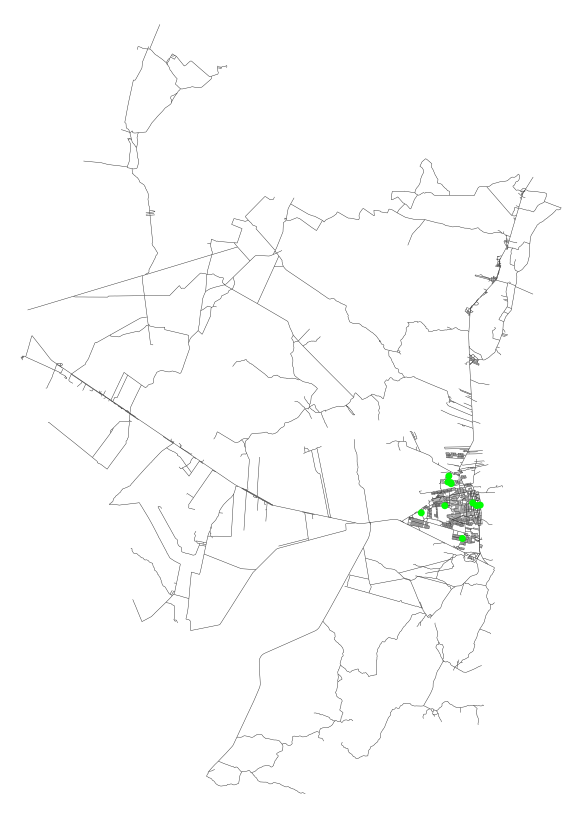

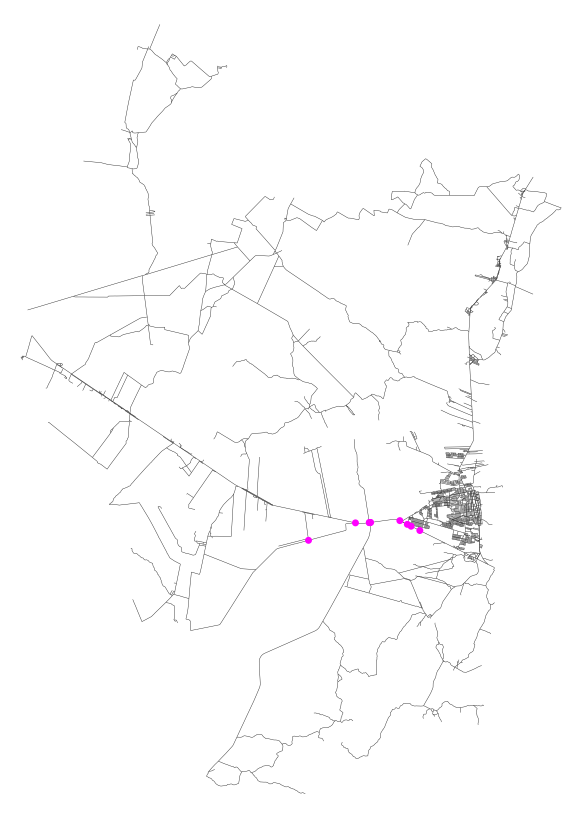

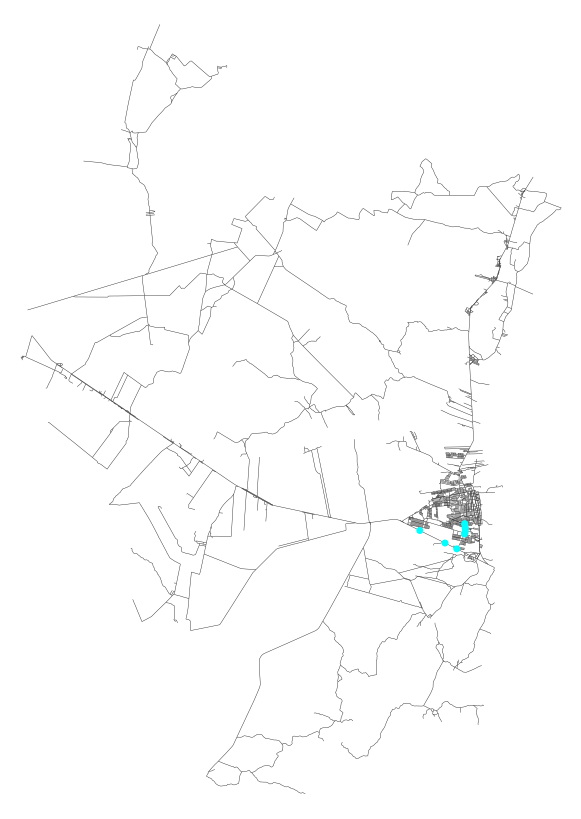

In [38]:

metricas_para_plotar = {
    'Degree': 'lime',
    'Betweenness': 'magenta',
    'Closeness': 'cyan'
}

for metrica, cor in metricas_para_plotar.items():
    print(f"{'='*60}")
    print(f"📍 GERANDO MAPA PARA O TOP 10 DE: {metrica.upper()}")
    print(f"{'='*60}")
    
    top_10_nos = df_metricas.sort_values(by=metrica, ascending=False).head(10).index.tolist()

    cores_dos_nos = []
    tamanhos_dos_nos = []

    for no in G_undirected.nodes():
        if no in top_10_nos:
            cores_dos_nos.append(cor)   
            tamanhos_dos_nos.append(25)
        else:
            cores_dos_nos.append('none')
            tamanhos_dos_nos.append(0)

    caminho_arquivo = f"images/grafo_top10_{metrica.lower()}.svg"

    fig, ax = ox.plot_graph(
        G_undirected,
        node_color=cores_dos_nos,
        node_size=tamanhos_dos_nos,
        node_zorder=3,      
        edge_color="#222222",   
        edge_linewidth=0.3,   
        bgcolor="black",
        show=False,
        save=True,
        filepath=caminho_arquivo,
        dpi=300
    )
    
    print(f"✅ Imagem salva com visualização limpa: '{caminho_arquivo}'\n")
    for no in top_10_nos:
        cruzamento_info = df_metricas.loc[no, 'Cruzamento']
        print(f"Nó {no}: {cruzamento_info}")
        
    print("\n")

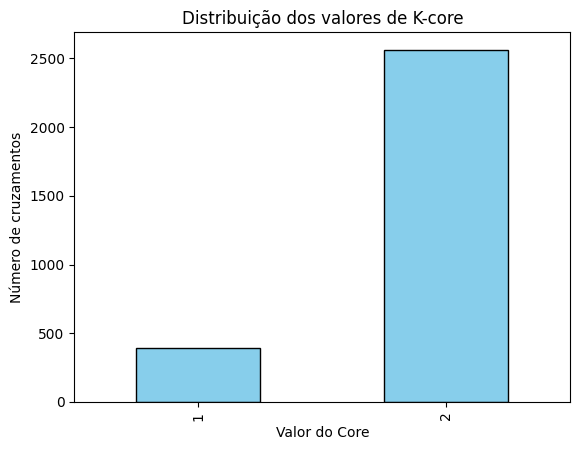

In [39]:
df_metricas['Core_Number'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribuição dos valores de K-core')
plt.xlabel('Valor do Core')
plt.ylabel('Número de cruzamentos')

plt.savefig('images/distribuicao_kcore.svg', dpi=300, bbox_inches='tight')


In [40]:
nx.set_node_attributes(G_undirected, df_metricas['Degree'].to_dict(), "degree")
nx.set_node_attributes(G_undirected, df_metricas['Betweenness'].to_dict(), "betweenness")
nx.set_node_attributes(G_undirected, df_metricas['Closeness'].to_dict(), "closeness")
nx.set_node_attributes(G_undirected, df_metricas['Core_Number'].to_dict(), "core_number")

G_gephi = nx.Graph(G_undirected)

for no, dados in G_gephi.nodes(data=True):
    dados['Latitude'] = float(dados['y'])
    dados['Longitude'] = float(dados['x'])
    
    for chave, valor in list(dados.items()):
        if isinstance(valor, list):
            dados[chave] = ", ".join(map(str, valor))

for u, v, dados in G_gephi.edges(data=True):
    
    if 'geometry' in dados:
        del dados['geometry']
        
    for chave, valor in list(dados.items()):
        if isinstance(valor, list):
            dados[chave] = ", ".join(map(str, valor))

nx.write_graphml(G_gephi, "graphs/assu_gephi_definitivo.graphml")

print(f"Sucesso! Grafo exportado com {G_gephi.number_of_nodes()} nós e {G_gephi.number_of_edges()} arestas!")

print("Arquivo 'graphs/assu_gephi_definitivo.graphml' exportado com sucesso!")

Sucesso! Grafo exportado com 2952 nós e 4290 arestas!
Arquivo 'graphs/assu_gephi_definitivo.graphml' exportado com sucesso!
